# Ejemplo de taller de redes neuronales con datos de SP500


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

!pip install yfinance
import yfinance as yf


warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']

precios_close.dropna(axis=1, inplace=True)

[*********************100%***********************]  23 of 23 completed


In [3]:
precios_close.dropna(axis=1, inplace=True)

In [4]:
returns = np.log(precios_close).diff().dropna()
returns.shape

(16184, 23)

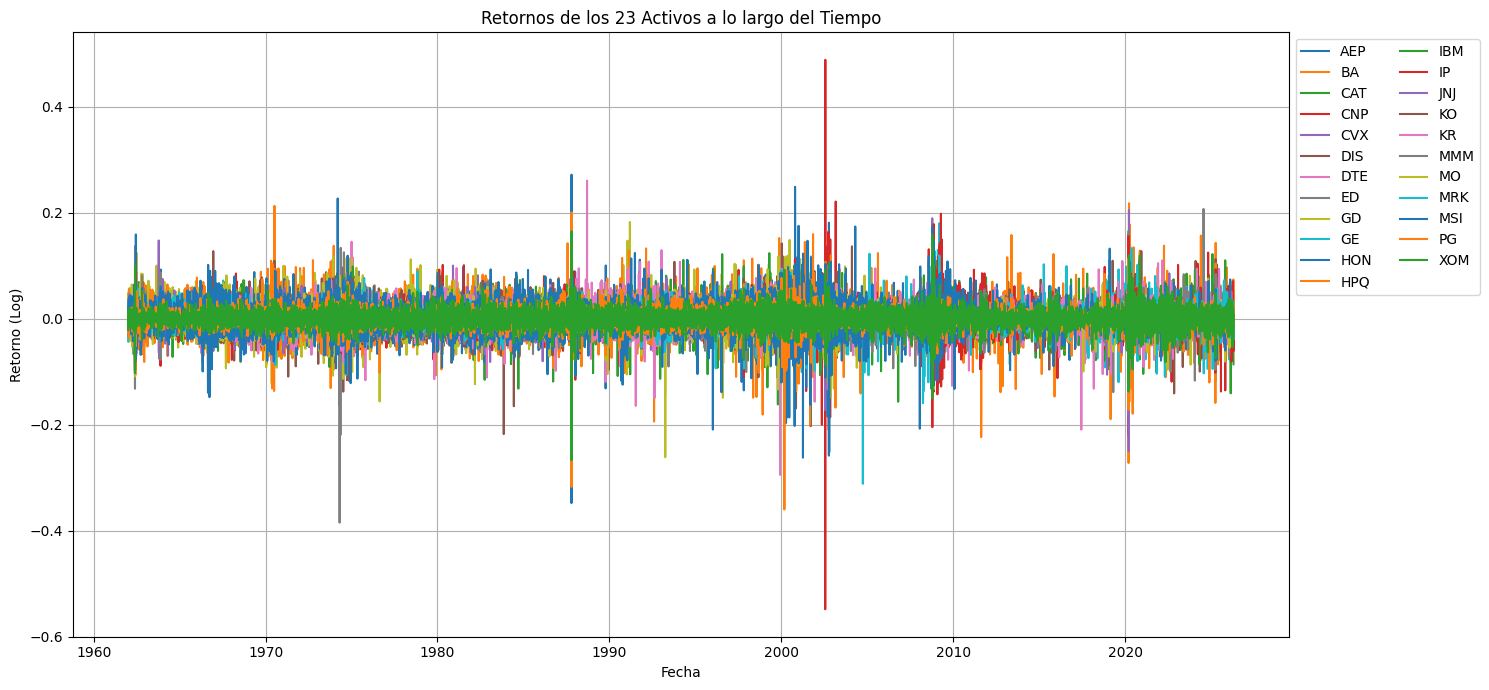

In [5]:
plt.figure(figsize=(15, 7))
plt.plot(returns)
plt.title('Retornos de los 23 Activos a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Retorno (Log)')
plt.legend(returns.columns, loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Partir los datos en ventanas

In [6]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

In [7]:
# Definir los tamaños de ventana
input_window_size = 30  # Por ejemplo, 10 días de retornos como entrada
output_window_size = 5 # Por ejemplo, el promedio del siguiente día como salida

# Generar series temporales para el conjunto de entrenamiento
X, y = create_time_series_data(returns, input_window_size, output_window_size)


In [8]:
print(X.shape)
print(y.shape)

(16150, 30, 23)
(16150, 23)


In [9]:
from sklearn.model_selection import train_test_split

# Set a random seed for reproducibility
RANDOM_SEED = 42

# Split the time series sequences X and y into training and testing sets (90% train, 10% test)
# shuffle=False is crucial for time series data to maintain chronological order
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X, y, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (14535, 30, 23)
Shape of y_train_seq: (14535, 23)
Shape of X_test_seq: (1615, 30, 23)
Shape of y_test_seq: (1615, 23)


# Red neuronal densa

In [10]:
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq, y_train_seq, test_size=0.05, shuffle=False, random_state=RANDOM_SEED
)

In [11]:
print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_train_seq: {X_val_seq.shape}")
print(f"Shape of y_train_seq: {y_val_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (13808, 30, 23)
Shape of y_train_seq: (13808, 23)
Shape of X_train_seq: (727, 30, 23)
Shape of y_train_seq: (727, 23)
Shape of X_test_seq: (1615, 30, 23)
Shape of y_test_seq: (1615, 23)


In [12]:

num_samples_train = X_train_seq.shape[0]
num_samples_val = X_val_seq.shape[0]
num_samples_test = X_test_seq.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat = X_train_seq.reshape(num_samples_train, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat = X_val_seq.reshape(num_samples_val, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat = X_test_seq.reshape(num_samples_test, -1)

print(f"Shape of X_train_flat: {X_train_flat.shape}")
print(f"Shape of X_valn_flat: {X_val_flat.shape}")
print(f"Shape of X_test_flat: {X_test_flat.shape}")

Shape of X_train_flat: (13808, 690)
Shape of X_valn_flat: (727, 690)
Shape of X_test_flat: (1615, 690)


In [13]:
import keras as keras
from keras.models import Sequential
from keras.layers import Dense

# DEFINICION DEL MODELO: anyadimos capas una a una

model = Sequential()
model.add(Dense(100, activation='relu', input_dim=(X_train_flat.shape[1])))
model.add(Dense(y_train_seq.shape[1]))

# DEFINICION DE FUNCIÓN DE COSTE, Y OPTIMIZADOR
model.compile(loss='mean_absolute_error',optimizer='Adam')



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# ENTRENAMIENTO
hist = model.fit(X_train_flat, y_train_seq,validation_split = 0.1,epochs=10)

Epoch 1/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 2/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 3/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 4/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 5/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 6/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 7/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 8/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 9/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 10/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0044


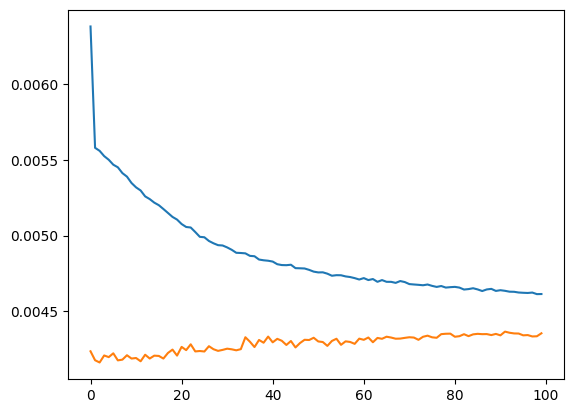

In [17]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

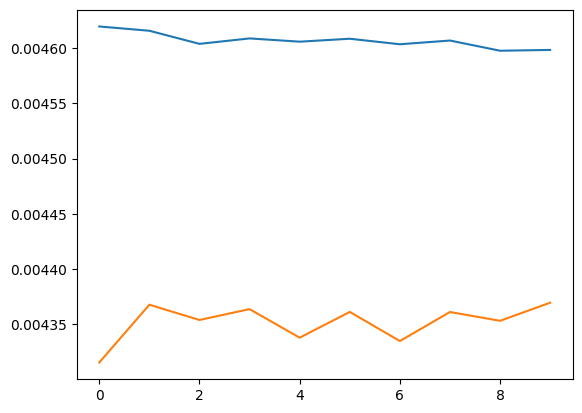

In [19]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

In [20]:

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_tr = model.predict(X_train_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_val = model.predict(X_val_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_ts = model.predict(X_test_flat)


432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [21]:
np.mean(np.abs(y_pred_linear_tr-y_train_seq))

np.float64(0.004572031086185473)

In [22]:
np.mean(np.abs(y_pred_linear_val-y_val_seq))

np.float64(0.00461454164613325)

In [23]:
np.mean(np.abs(y_pred_linear_ts-y_test_seq))

np.float64(0.006605842155691637)

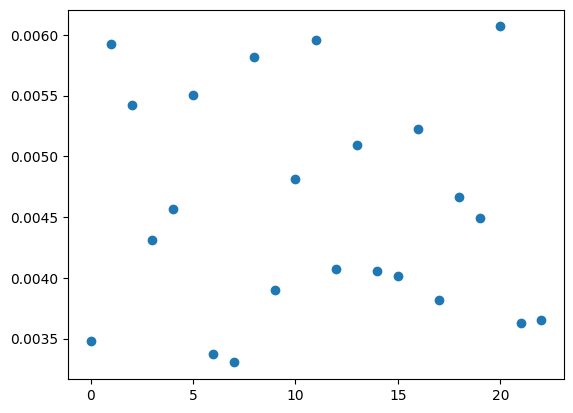

In [24]:
plt.plot(np.mean(np.abs(y_pred_linear_tr-y_train_seq),axis=0),'o')